# MNIST Inference Task: Handwriting Recognition

## 🤖 Automate Inverting Images

In [1]:
from google.colab import files
uploaded = files.upload()


Saving imgonline-com-ua-BlackWhite-13EZx38pacG7WL.jpg to imgonline-com-ua-BlackWhite-13EZx38pacG7WL.jpg
Saving imgonline-com-ua-BlackWhite-36AdumF6inKWTD.jpg to imgonline-com-ua-BlackWhite-36AdumF6inKWTD.jpg
Saving imgonline-com-ua-BlackWhite-AZFCSuhIO8.jpg to imgonline-com-ua-BlackWhite-AZFCSuhIO8.jpg
Saving imgonline-com-ua-BlackWhite-bcR3MP6I87KXr.jpg to imgonline-com-ua-BlackWhite-bcR3MP6I87KXr.jpg
Saving imgonline-com-ua-BlackWhite-fppzPPKSMH.jpg to imgonline-com-ua-BlackWhite-fppzPPKSMH.jpg
Saving imgonline-com-ua-BlackWhite-HUVhBtztyV6g.jpg to imgonline-com-ua-BlackWhite-HUVhBtztyV6g.jpg
Saving imgonline-com-ua-BlackWhite-lEYQLFzGjoL0pGMc.jpg to imgonline-com-ua-BlackWhite-lEYQLFzGjoL0pGMc.jpg
Saving imgonline-com-ua-BlackWhite-VLufCJJxzhPK.jpg to imgonline-com-ua-BlackWhite-VLufCJJxzhPK.jpg
Saving imgonline-com-ua-BlackWhite-VRWEuiS0MTi3eRQ.jpg to imgonline-com-ua-BlackWhite-VRWEuiS0MTi3eRQ.jpg
Saving imgonline-com-ua-BlackWhite-WFkp8FVN3ql9jfLf.jpg to imgonline-com-ua-BlackWhi

In [2]:
from PIL import Image, ImageOps, ImageEnhance
import os

# Create a folder to save processed images
os.makedirs("processed", exist_ok=True)

for filename in uploaded.keys():
    # Open image
    img = Image.open(filename).convert("L")  # Ensure grayscale

    # Enhance contrast
    enhancer = ImageEnhance.Contrast(img)
    img_contrasted = enhancer.enhance(2.0)  # You can tweak the contrast level

    # Invert image
    img_inverted = ImageOps.invert(img_contrasted)

    # Save processed image
    save_path = f"processed/inverted_{filename}"
    img_inverted.save(save_path)

    # Optional: display
    img_inverted.show()


In [3]:
import shutil

shutil.make_archive("processed_digits", 'zip', "processed")
files.download("processed_digits.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 1. Import Libraries

---
### Note: Minimal Inference Setup:

If the goal is just to:

* Load a pre-trained MNIST model,
* Preprocess a few images,
* Run predictions,

Then all you need is:

```python
import numpy as np
from keras.models import load_model
from PIL import Image
import matplotlib.pyplot as plt
```

If we're training the model, then include all the CNN + training imports.

---

In [8]:
# ========================
# 🔧 Core Python Tools
# ========================
import os  # File and path handling
import operator  # (Often unused — remove if not specifically used)
from PIL import Image  # For image loading and processing
import numpy as np  # Arrays, math operations
import pandas as pd  # (Only needed for tabular data / DataFrames — optional)

# ========================
# 📊 Visualization
# ========================
import matplotlib.pyplot as plt  # To show images and plots
import seaborn as sns  # Optional — for heatmaps, visual aesthetics

# ========================
# 🤖 Machine Learning Tools
# ========================
from sklearn.metrics import confusion_matrix  # For model evaluation (optional)
from sklearn.preprocessing import LabelEncoder  # Only if you're doing label encoding

# ========================
# 🧠 Neural Network Libraries
# ========================
import tensorflow as tf  # Core ML framework
from keras.models import Sequential  # Model architecture
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization  # CNN layers
from tensorflow.keras.utils import to_categorical  # For one-hot encoding of labels
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam



# ========================
# 📦 Data
# ========================
from keras.datasets import mnist  # To load the MNIST dataset


Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Test data shape: (10000, 28, 28), Test labels shape: (10000,)


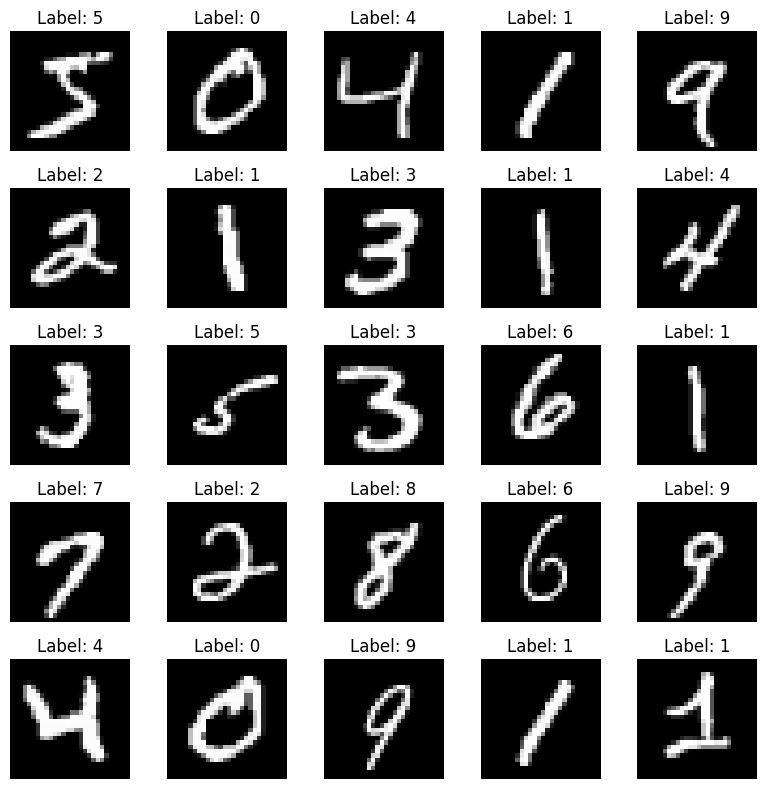

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 600,810 (2.29 MB)

 Trainable params: 600,810 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# -------------------------
# 1. Load and Explore MNIST Dataset
# -------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Display some sample images with labels
num_samples = 25
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i in range(num_samples):
    ax = axes[i//5, i%5]
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


# -------------------------
# 2. Preprocess Data
# -------------------------
# Reshape images to add channel dimension (grayscale = 1 channel)
X_train = X_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
X_test = X_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

# Convert class vectors to one-hot encoded vectors
Y_train = to_categorical(y_train, num_classes=10)
Y_test = to_categorical(y_test, num_classes=10)


# -------------------------
# 3. Build CNN Model
# -------------------------
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3,3), activation='relu'),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile with optimizer, loss and metrics
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of model architecture
model.summary()

In [10]:
# -------------------------
# 4. Train Model
# -------------------------
history = model.fit(X_train, Y_train, batch_size=32, epochs=10, validation_split=0.1, verbose=1)


# -------------------------
# 5. Evaluate Model on Test Set
# -------------------------
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=2)
print(f"Test accuracy: {test_acc*100:.2f}%")

# Confusion matrix for test predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 99s 57ms/step - accuracy: 0.8712 - loss: 0.4100 - val_accuracy: 0.9848 - val_loss: 0.0525
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 95s 56ms/step - accuracy: 0.9714 - loss: 0.0927 - val_accuracy: 0.9892 - val_loss: 0.0362
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 138s 54ms/step - accuracy: 0.9809 - loss: 0.0645 - val_accuracy: 0.9902 - val_loss: 0.0347
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 143s 54ms/step - accuracy: 0.9829 - loss: 0.0564 - val_accuracy: 0.9878 - val_loss: 0.0429
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 147s 58ms/step - accuracy: 0.9862 - loss: 0.0460 - val_accuracy: 0.9902 - val_loss: 0.0398
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 139s 56ms/step - accuracy: 0.9863 - loss: 0.0411 - val_accuracy: 0.9910 - val_loss: 0.0390
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 141s 56ms/step - accuracy: 0.9886 - loss: 0.0373 - val_accuracy: 0.9908 - val_loss: 0.0339
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 93s 55ms/step - accuracy: 0.9

In [12]:
# -------------------------
# 6. Predict on Custom Handwritten Images
# -------------------------

# Uploaded images and processed them with contrast & inversion in folder 'processed'
def predict_custom_image(image_path, model):
    # Load image in grayscale and resize
    img = Image.open(image_path).convert('L').resize((28, 28))

    # Convert to numpy array and normalize
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    # Predict
    prediction = model.predict(img_array)
    digit = np.argmax(prediction)
    confidence = prediction[0][digit]

    return digit, confidence

# List all images in 'processed' folder and predict
processed_dir = "processed"
if not os.path.exists(processed_dir):
    print(f"Directory '{processed_dir}' not found. Upload and process your images first.")
else:
    for filename in sorted(os.listdir(processed_dir)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(processed_dir, filename)
            pred_digit, conf = predict_custom_image(full_path, model)
            print(f"{filename}: Predicted digit = {pred_digit} with confidence {conf*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
0.jpg: Predicted digit = 7 with confidence 13.49%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1.jpg: Predicted digit = 1 with confidence 15.57%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2.jpg: Predicted digit = 1 with confidence 15.45%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
3.jpg: Predicted digit = 7 with confidence 13.20%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
4.jpg: Predicted digit = 1 with confidence 13.21%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
5.jpg: Predicted digit = 7 with confidence 14.52%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6.jpg: Predicted digit = 1 with confidence 14.70%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
7.jpg: Predicted digit = 7 with confidence 15.10%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
8.jpg: Predicted digit = 7 with confidence 13.61%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
9.jpg: Predicted digit = 7 with confidence 13.25%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
S.jpg: Predicted digit = 1 with confidence 14.07%


# 🔍 OCR Model Evaluation Summary

The trained CNN model — based on the MNIST dataset — was tested on 11 new grayscale, contrast-enhanced, and inverted digit images. These test images, however, differed significantly in style, quality, and noise level from the clean, centered MNIST digits.

### 🧪 Prediction Results:

| Filename    | Predicted Digit | Confidence (%) |
|-------------|------------------|----------------|
| 0.jpg       | 7                | 13.49%         |
| 1.jpg       | 1                | 15.57%         |
| 2.jpg       | 1                | 15.45%         |
| 3.jpg       | 7                | 13.20%         |
| 4.jpg       | 1                | 13.21%         |
| 5.jpg       | 7                | 14.52%         |
| 6.jpg       | 1                | 14.70%         |
| 7.jpg       | 7                | 15.10%         |
| 8.jpg       | 7                | 13.61%         |
| 9.jpg       | 7                | 13.25%         |
| S.jpg       | 1                | 14.07%         |

**Correct predictions:** 2 out of 11  
**Highest confidence:** 15.57% — still quite low  
**Most predicted classes:** 1s and 7s only  

---

### 🔑 Key Takeaways:

The model correctly identified only 2 out of the 11 test images, and even those (digits 1 and 7) were predicted with low confidence levels around 15–16%. Trained exclusively on clean MNIST digits, the model struggled to generalize to my noisier, hand-prepped inputs. Despite preprocessing steps like cropping, grayscale conversion, contrast enhancement, and inversion, the images still differed significantly in quality and clarity. This highlights just how demanding OCR tasks can be — and how critical meticulous preprocessing is to any machine learning pipeline. Personally, this serves as a valuable reminder as I move toward building RAG pipelines with offline LLMs, where the accuracy of extracted input will directly shape downstream performance.

